In [1]:
%load_ext autoreload
%autoreload 2

import sys
from hypnose_behavior.io.paths import get_repo_root
from hypnose_behavior.io.save import use_style

sys.path.insert(0, str(get_repo_root() / "scripts" / "modelling"))
from switchpoint_analysis import run_analysis, run_permutation, run_logistic_diagnostic, run_residual_autocorrelation, run_qlearning_sweep
%matplotlib widget
use_style("presentation_style")

In [3]:
subjids = [40, 45, 48, 50, 66]
date_ranges = {40: (20251125, 20251231), 45: (20260213, 20260306), 48: (20260205, 20260306), 50: (20260225, 20260313), 66: (20260903, 20260915)}
subjids_2 = [60, 61, 62, 63, 66]
date_ranges_2 = {60: (20260903, 20260925), 61: (20260903, 20260925), 62: (20260903, 20260925), 63: (20260909, 20260925), 66: (20260903, 20260925)}


[switchpoint] Subject 60 | reward A (538 trials, 15 sessions)
  tau (trial index) = 326, global trial id 621, in session 20260917
  p1 = 0.101 -> p2 = 0.939
  95% HDI = [320, 327], width = 8 trials
  FWHM    = [324, 326], width = 3 trials
  model       k      loglik        AIC        BIC
  constant    1    -367.808      737.6      741.9  
  switch      3    -155.738      317.5      330.3  
  logistic    4    -142.701      293.4      310.6  (start switchpoint)
  switch2     5    -133.227      276.5      297.9  <-AIC <-BIC
  qlearning   4    -143.128      294.3      311.4  
  nesting: OK (constant <= switch <= logistic; switch2 monotone-gated)
  best model (BIC): switch2 -- tau1 = 240, tau2 = 326, p1 = 0.029 -> p2 = 0.302 -> p3 = 0.939
  q-learning variant        alpha        b  Q0_short  Q0_long   kappa       nll       AIC       BIC  starts
  qlearn_free             0.03386    2.928    -1.471   -0.626       -   143.128     294.3     311.4  32/32
                        generative: 92.6

C:\Users\HarrisLab\Desktop\Repos\hypnose\hypnose-behavior\src\hypnose_behavior\visualization\modelling\switchpoint\plots.py:158: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(8, 3.4))


[switchpoint] Subject 62: saved 8 figure(s) to \\ceph-gw02.hpc.swc.ucl.ac.uk\harris\hypnose\derivatives\sub-062_id-426\figures

[switchpoint] Subject 63 | reward A (328 trials, 12 sessions)
  tau (trial index) = 111, global trial id 228, in session 20260914
  p1 = 0.081 -> p2 = 0.323
  95% HDI = [98, 116], width = 19 trials
  FWHM    = [109, 111], width = 3 trials
  model       k      loglik        AIC        BIC
  constant    1    -181.076      364.2      367.9  
  switch      3    -167.685      341.4      352.7  <-AIC <-BIC
  logistic    4    -167.685      343.4      358.5  (start q30/slope5)
  switch2     5    -166.416      342.8      361.8  
  qlearning   4    -172.806      353.6      368.8  
  nesting: OK (constant <= switch <= logistic; switch2 monotone-gated)
  best model (BIC): switch -- tau = 111, p1 = 0.081 -> p2 = 0.323
  q-learning variant        alpha        b  Q0_short  Q0_long   kappa       nll       AIC       BIC  starts
  qlearn_free            0.003967   0.3866     3.

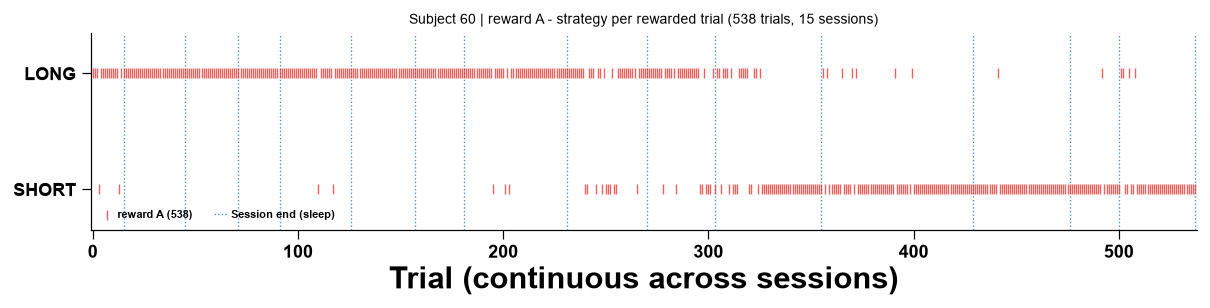

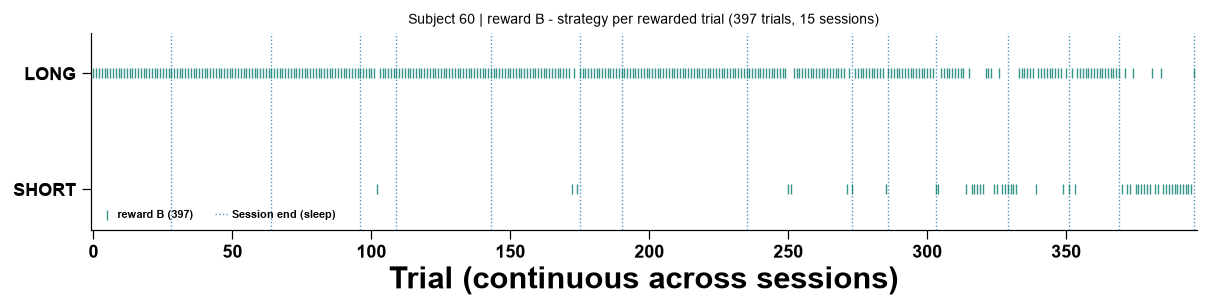

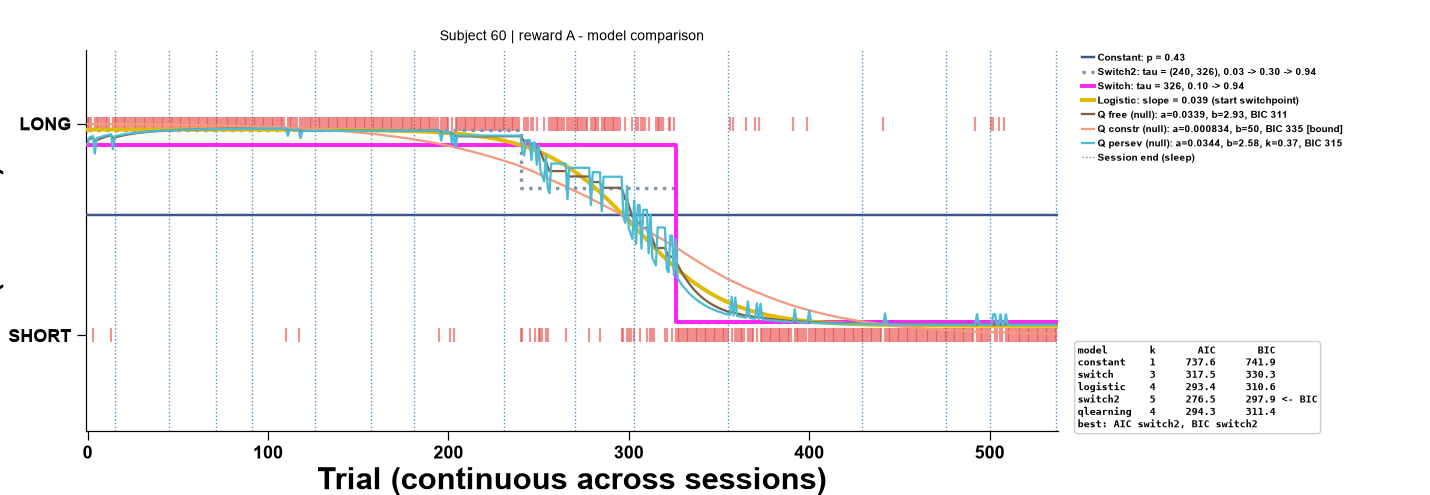

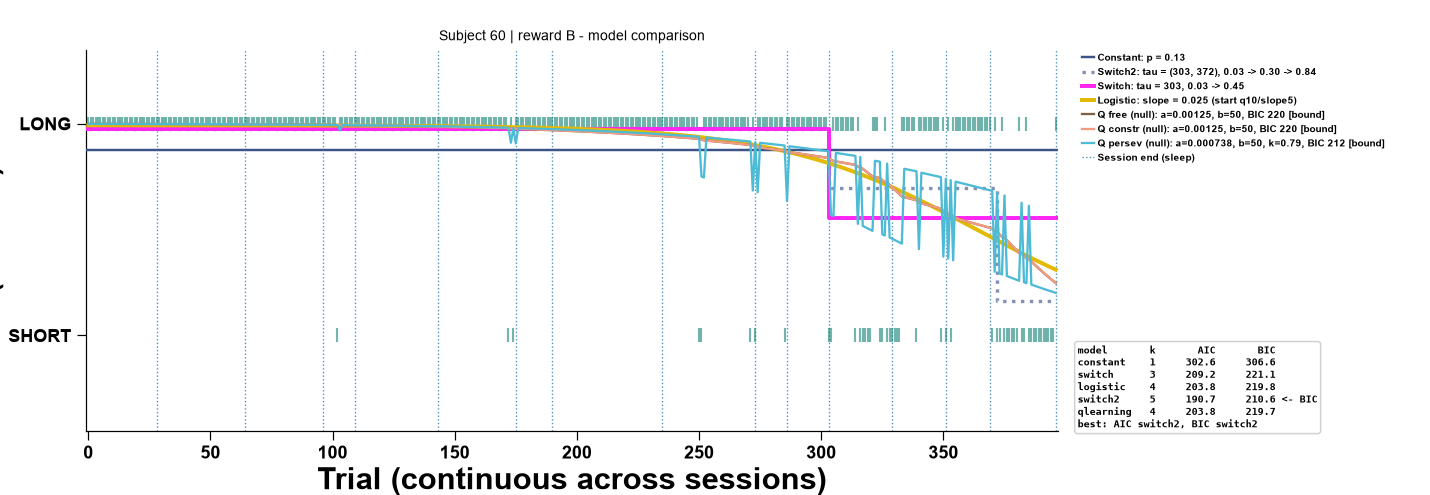

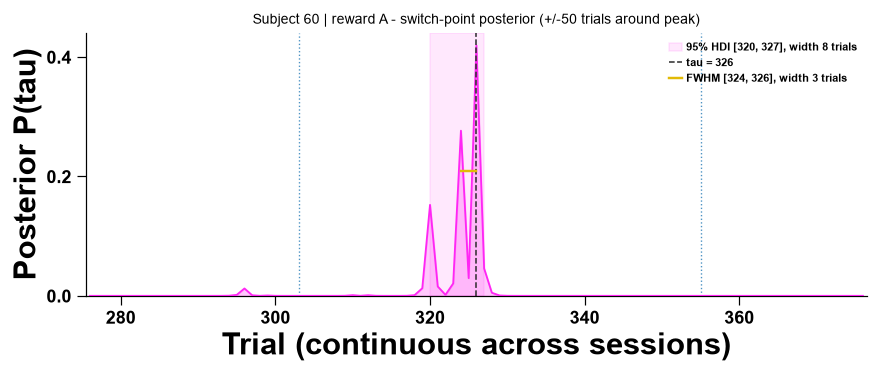

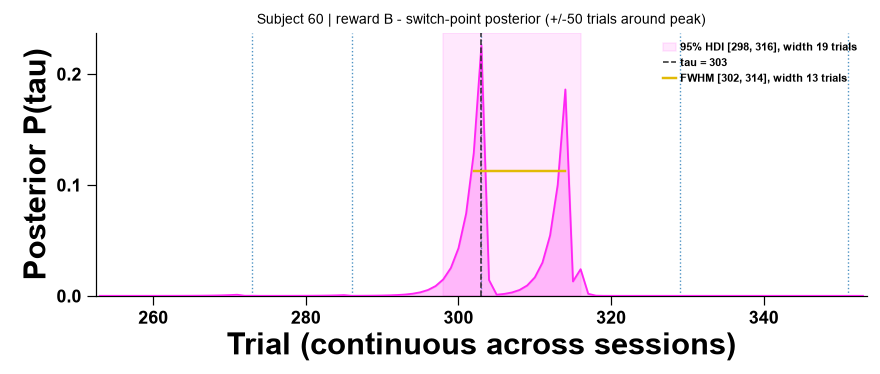

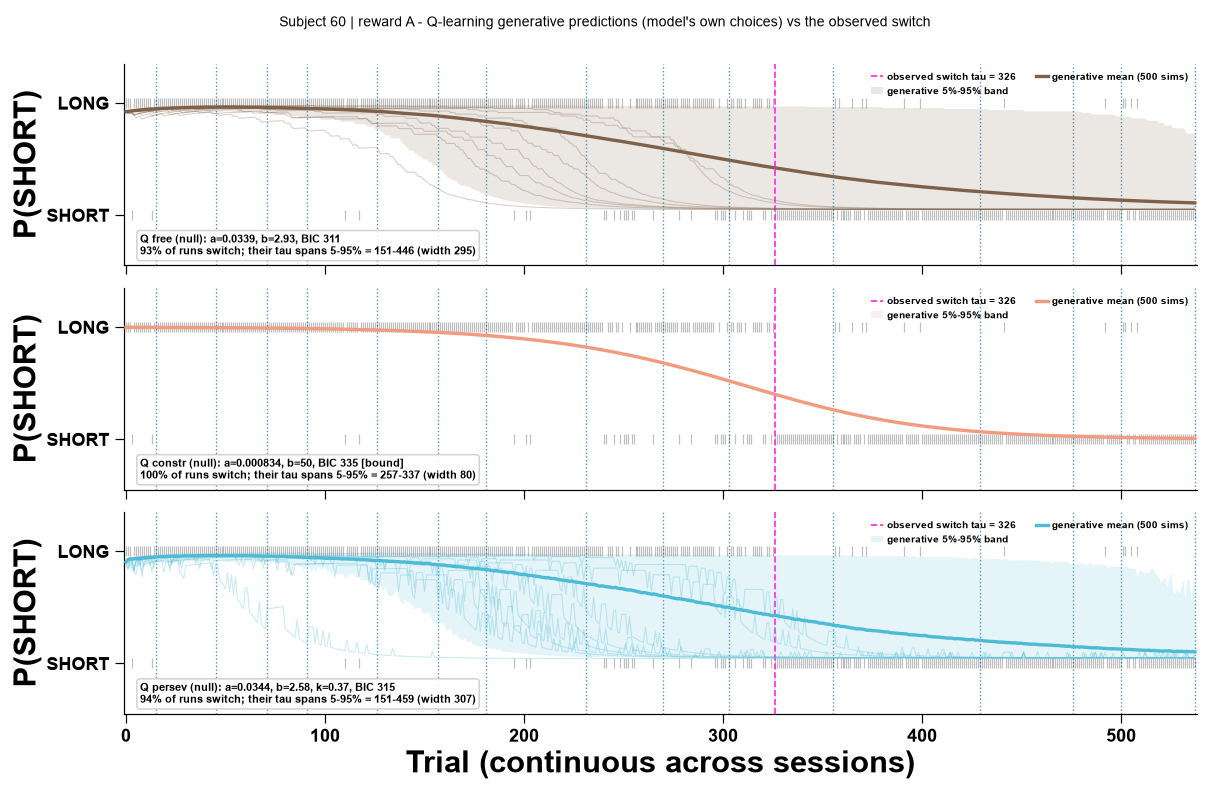

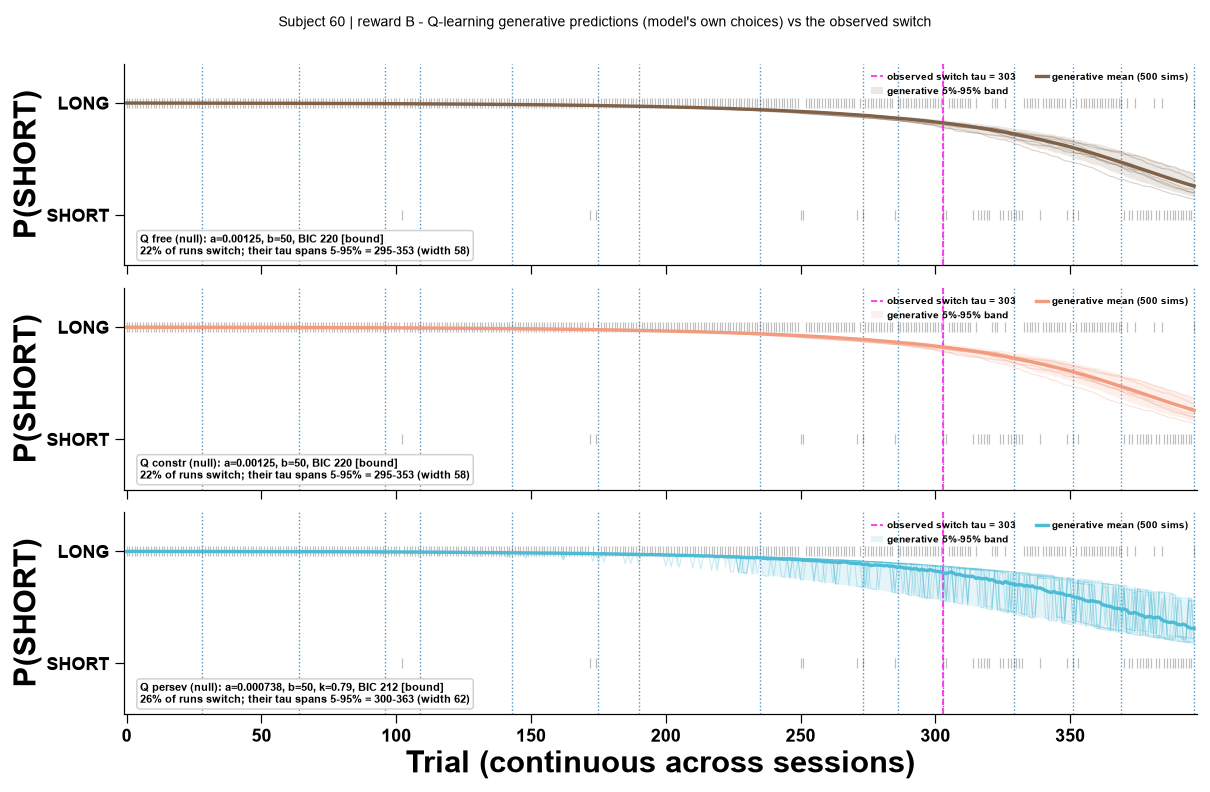

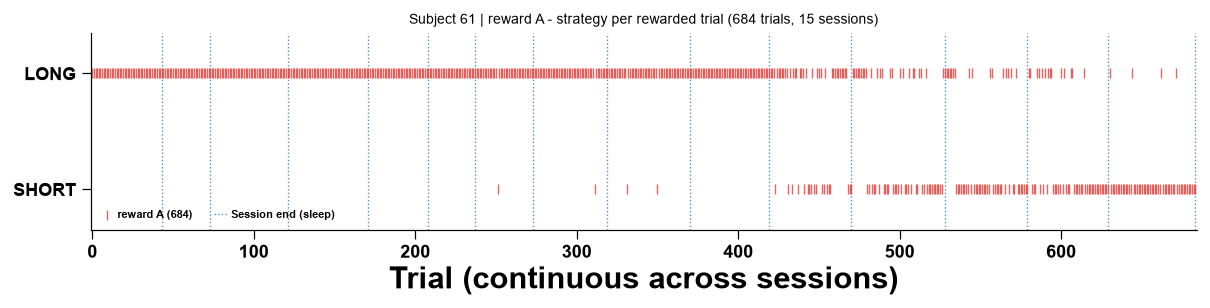

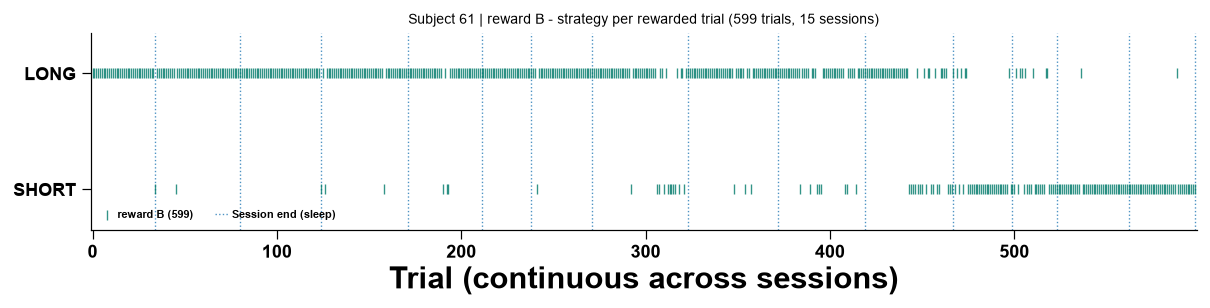

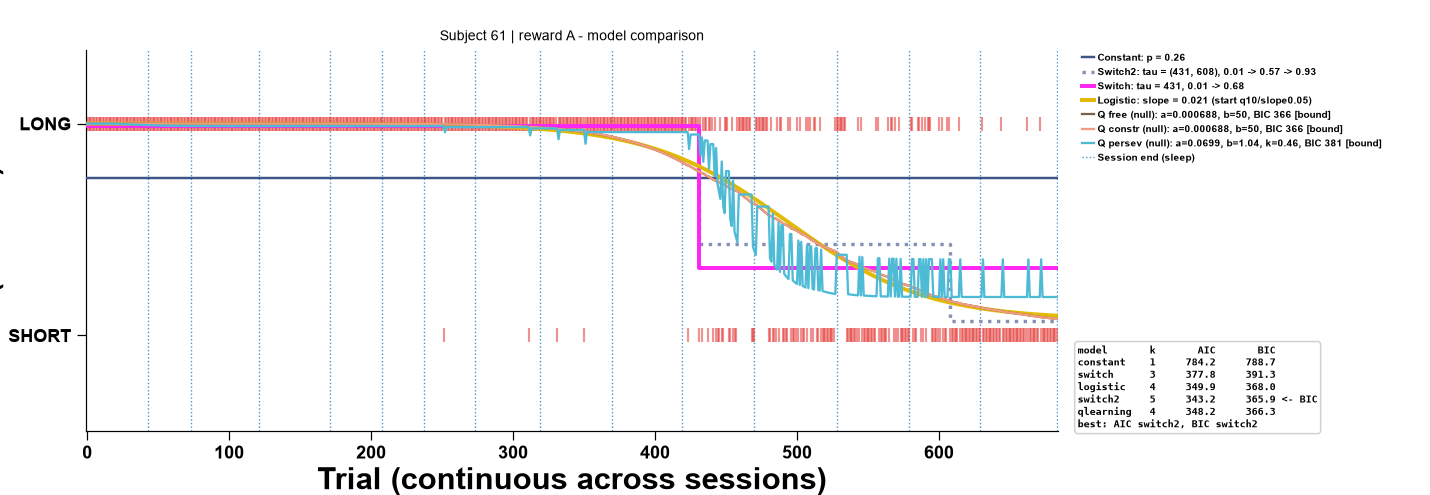

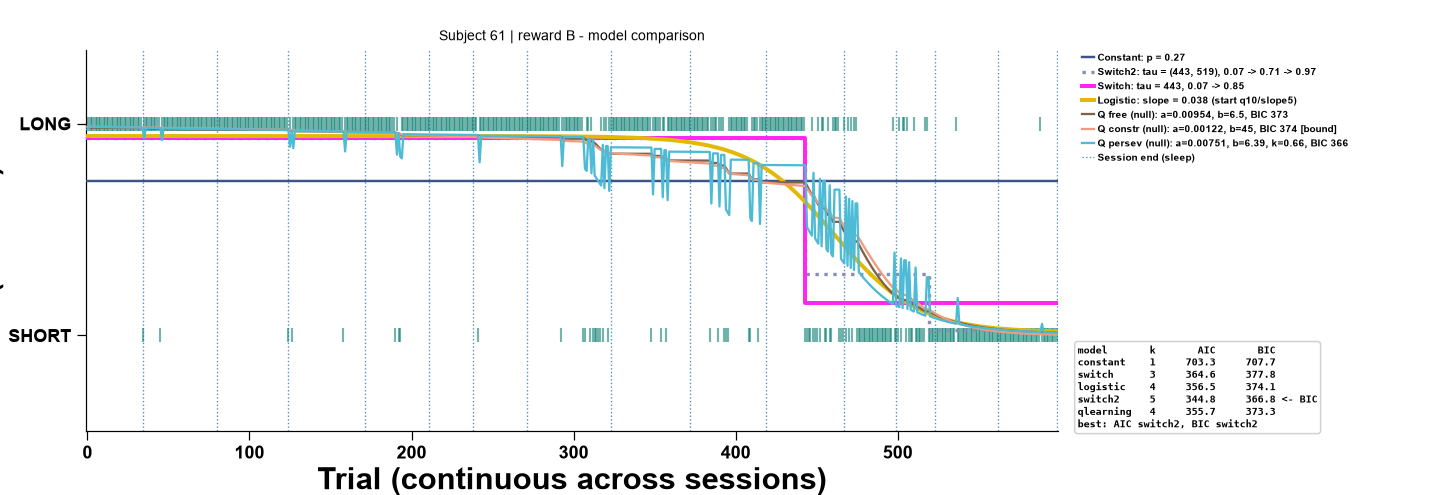

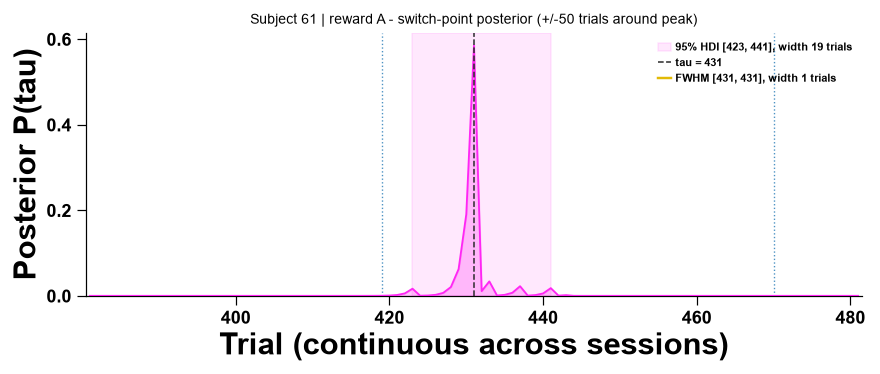

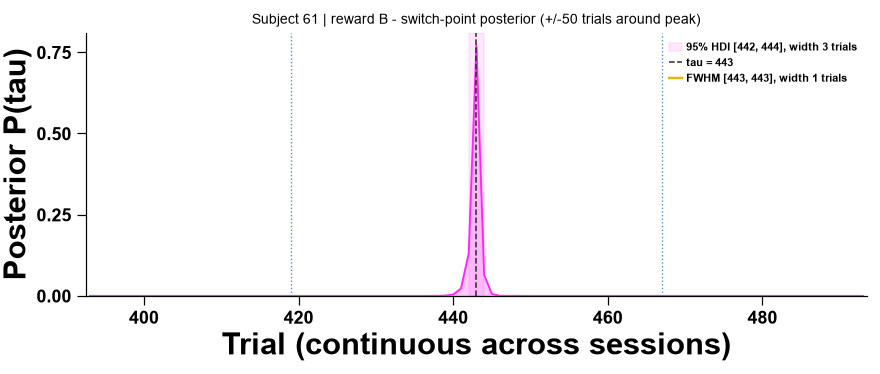

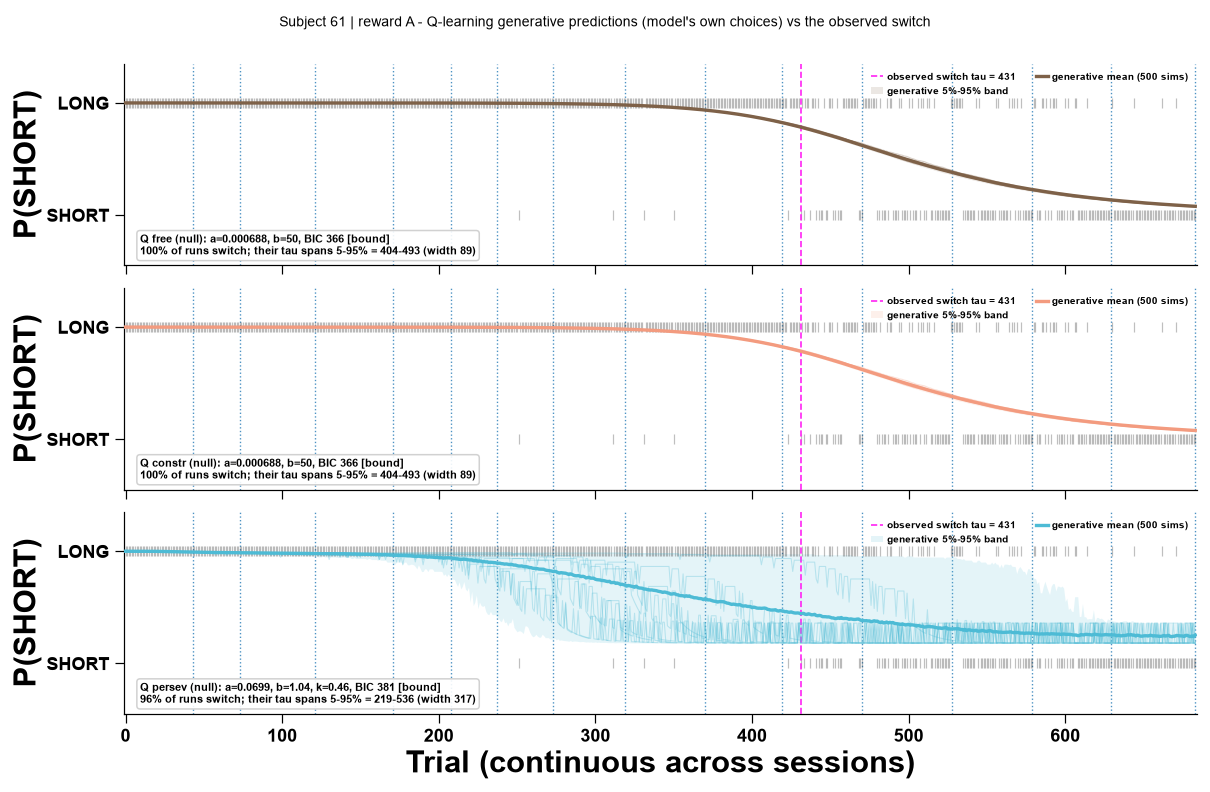

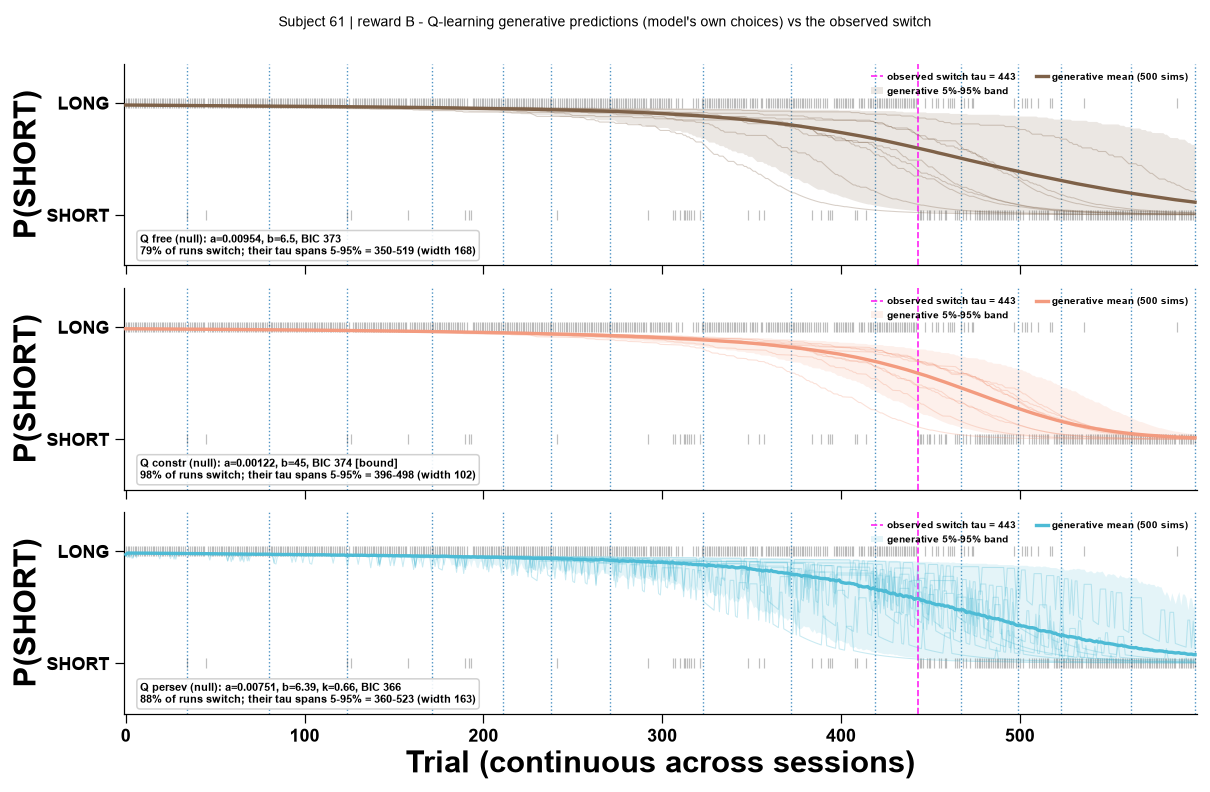

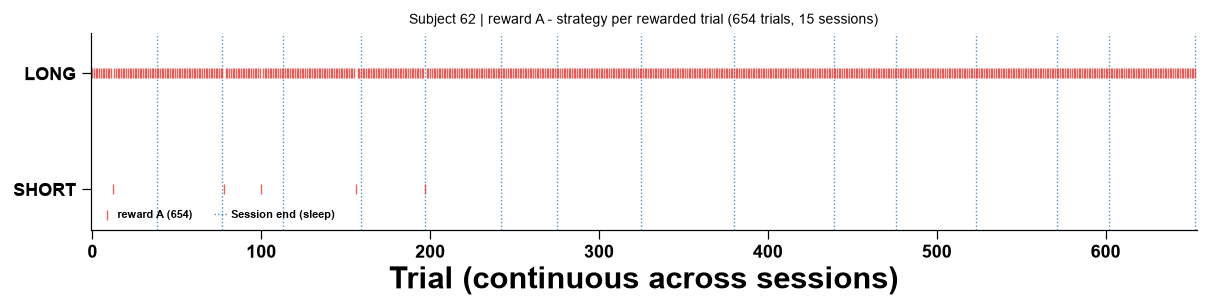

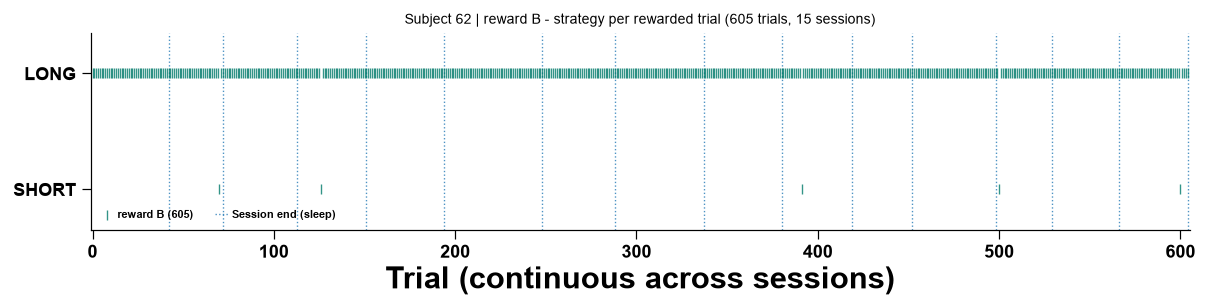

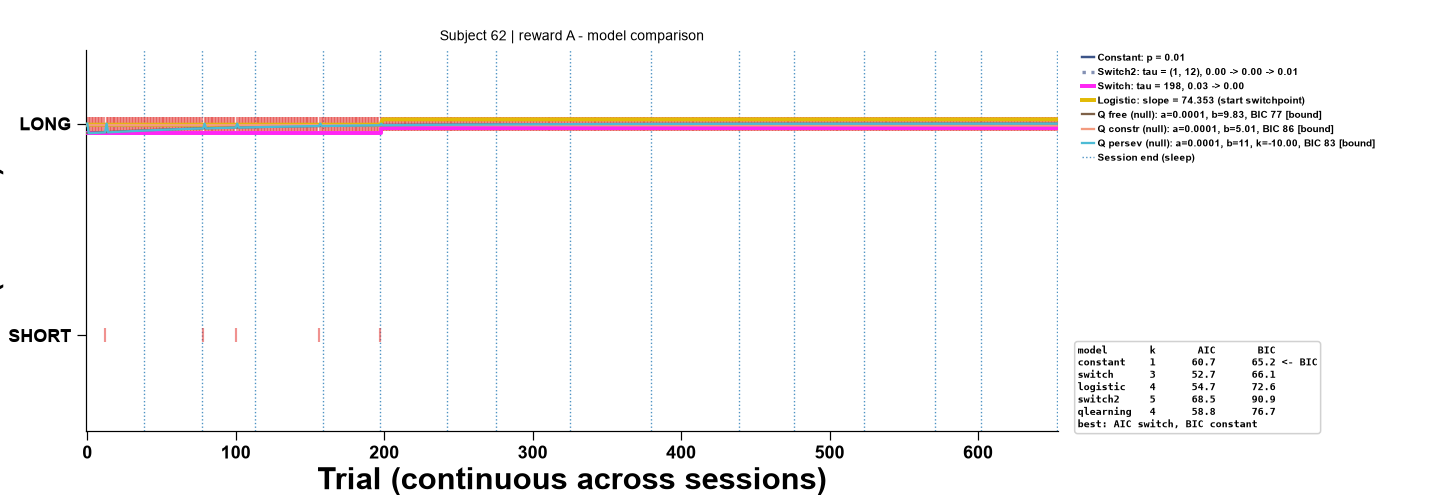

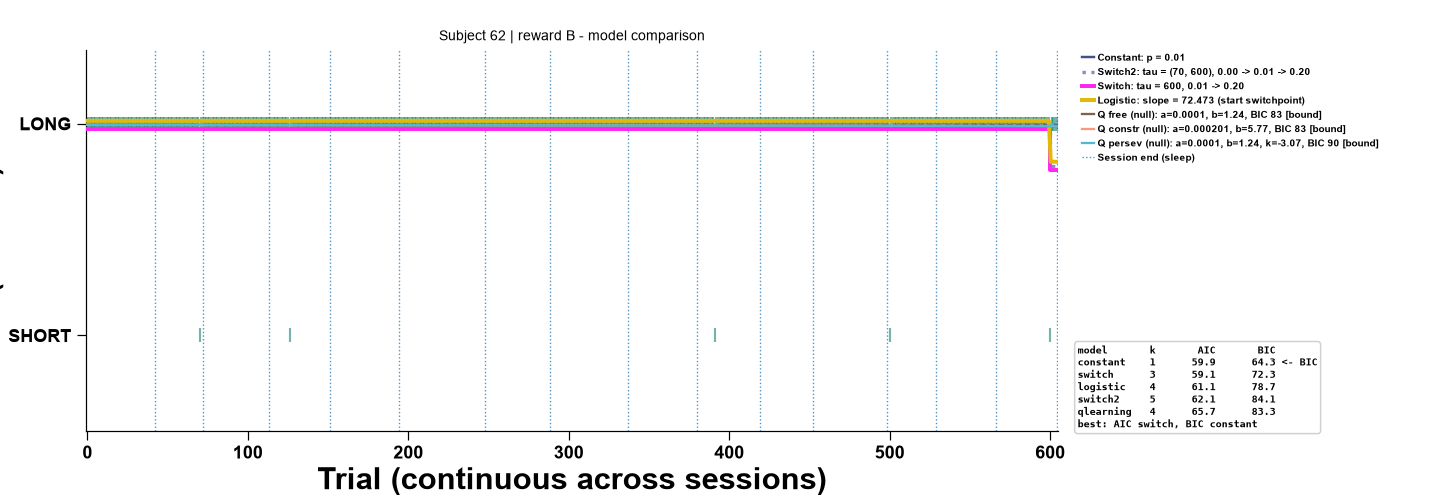

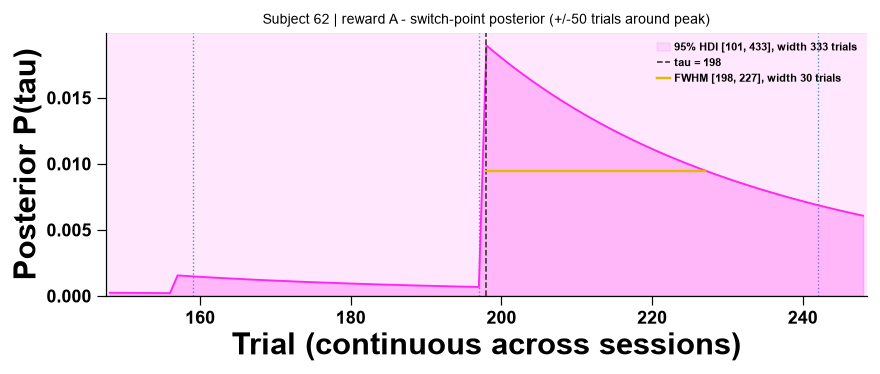

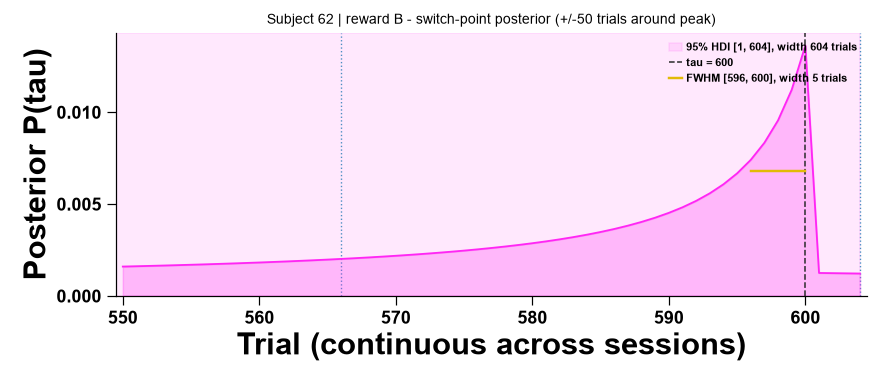

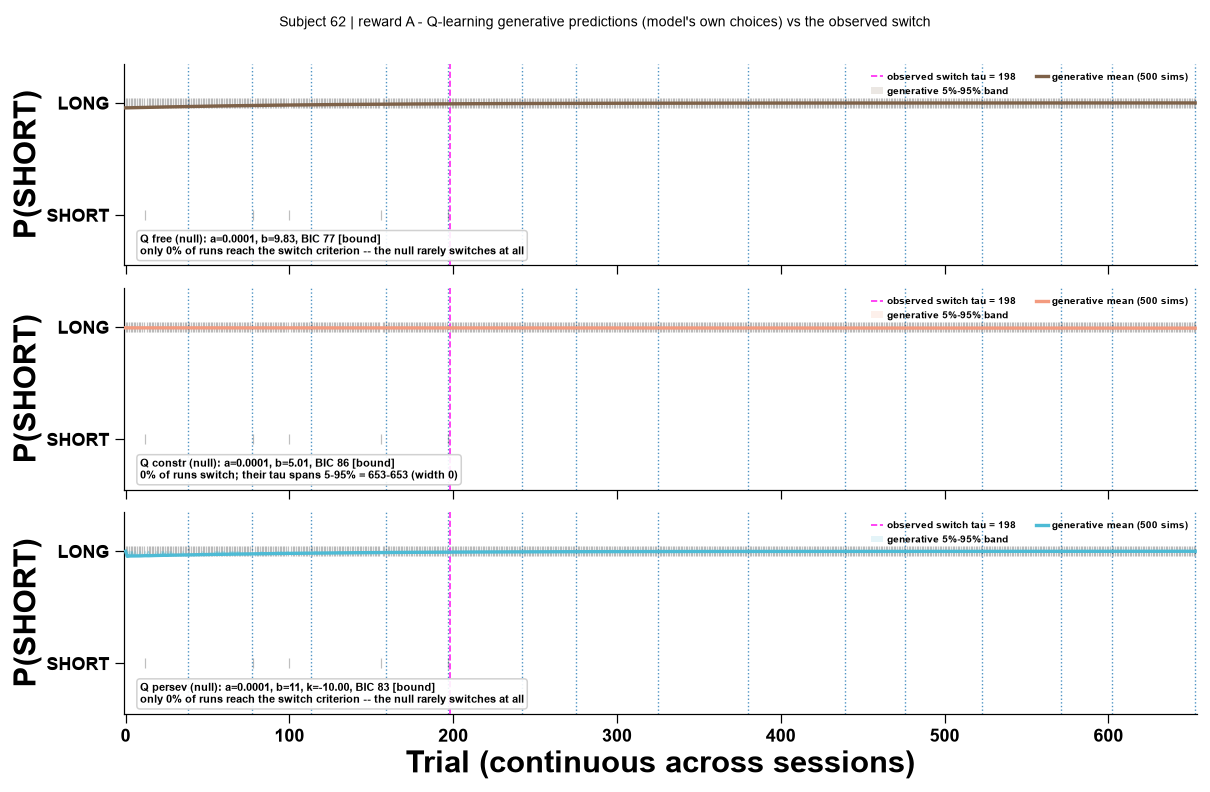

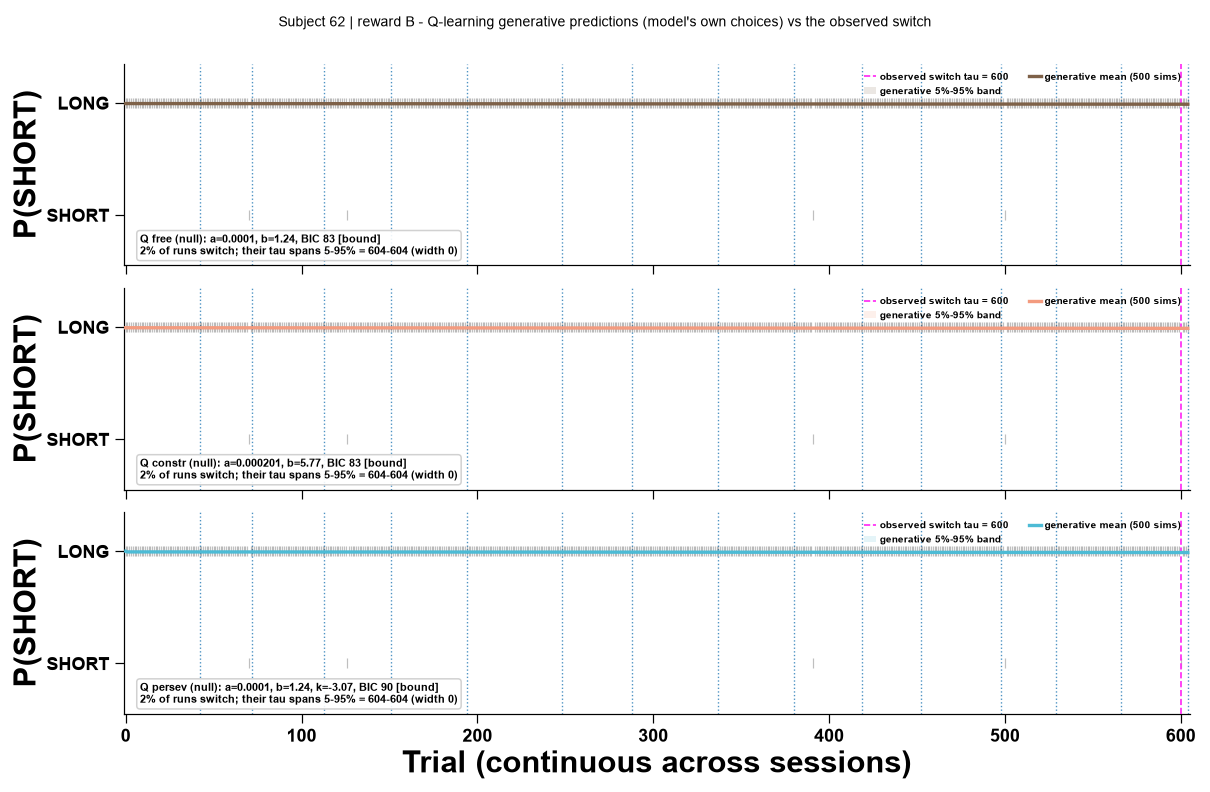

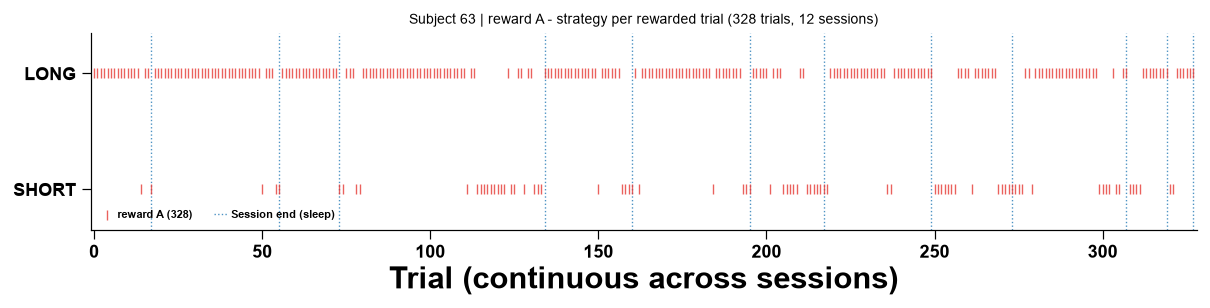

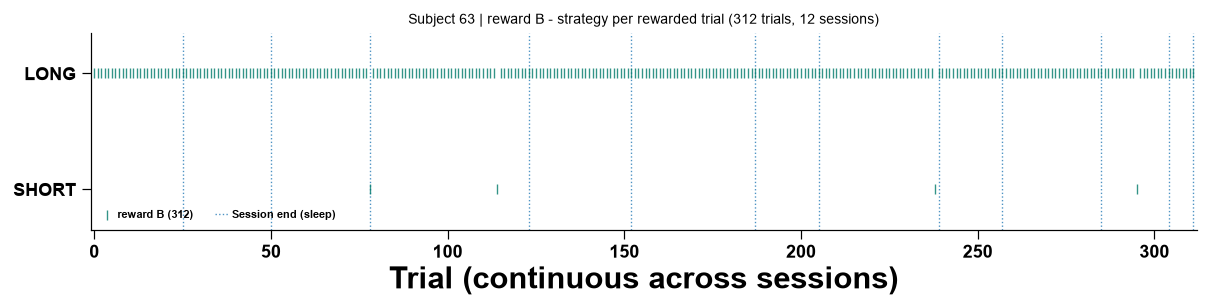

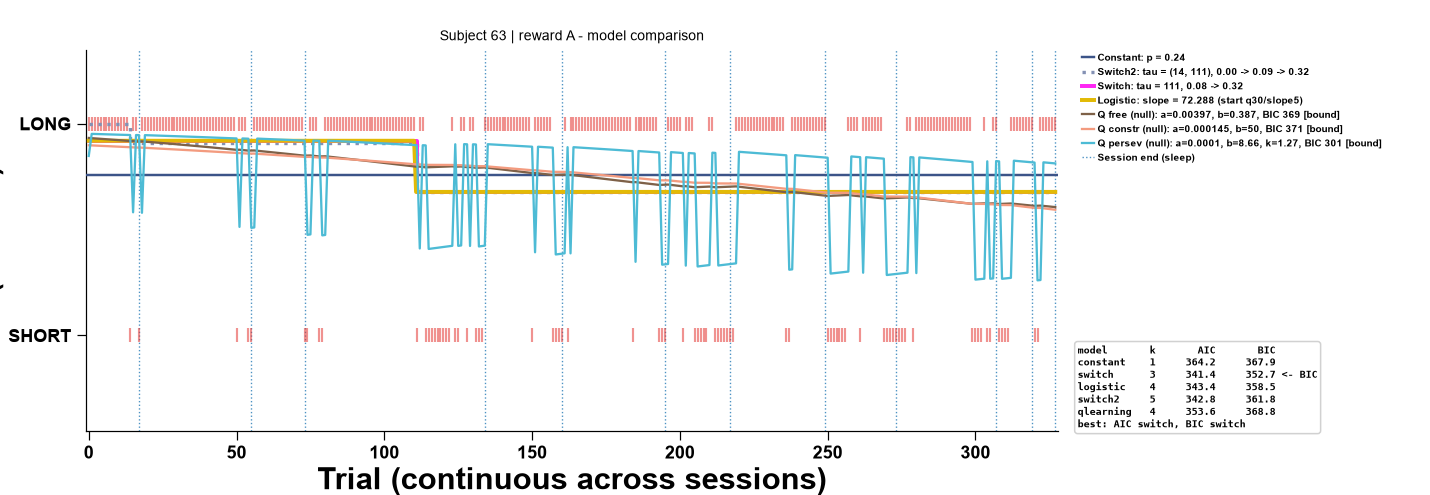

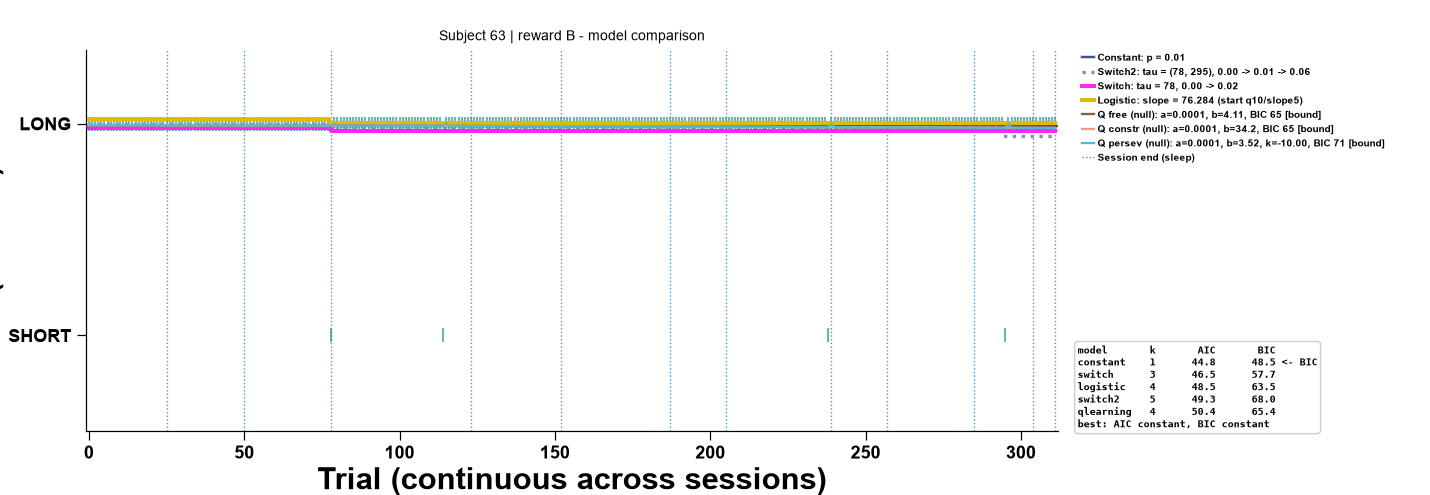

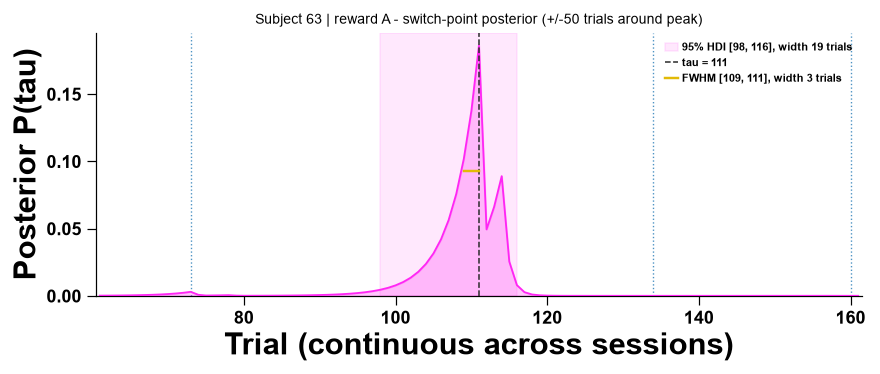

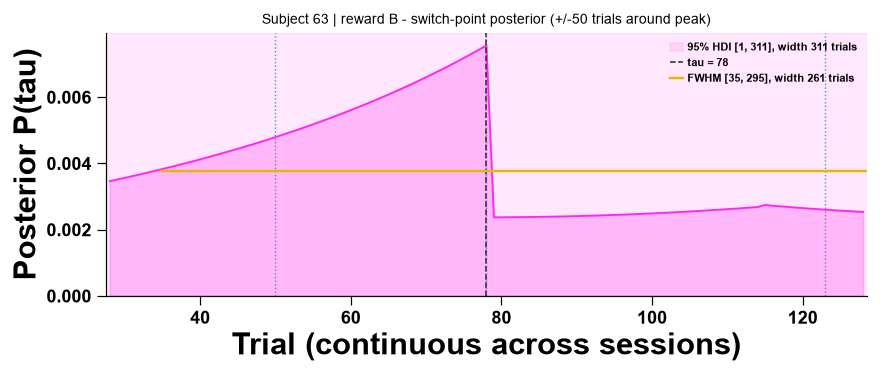

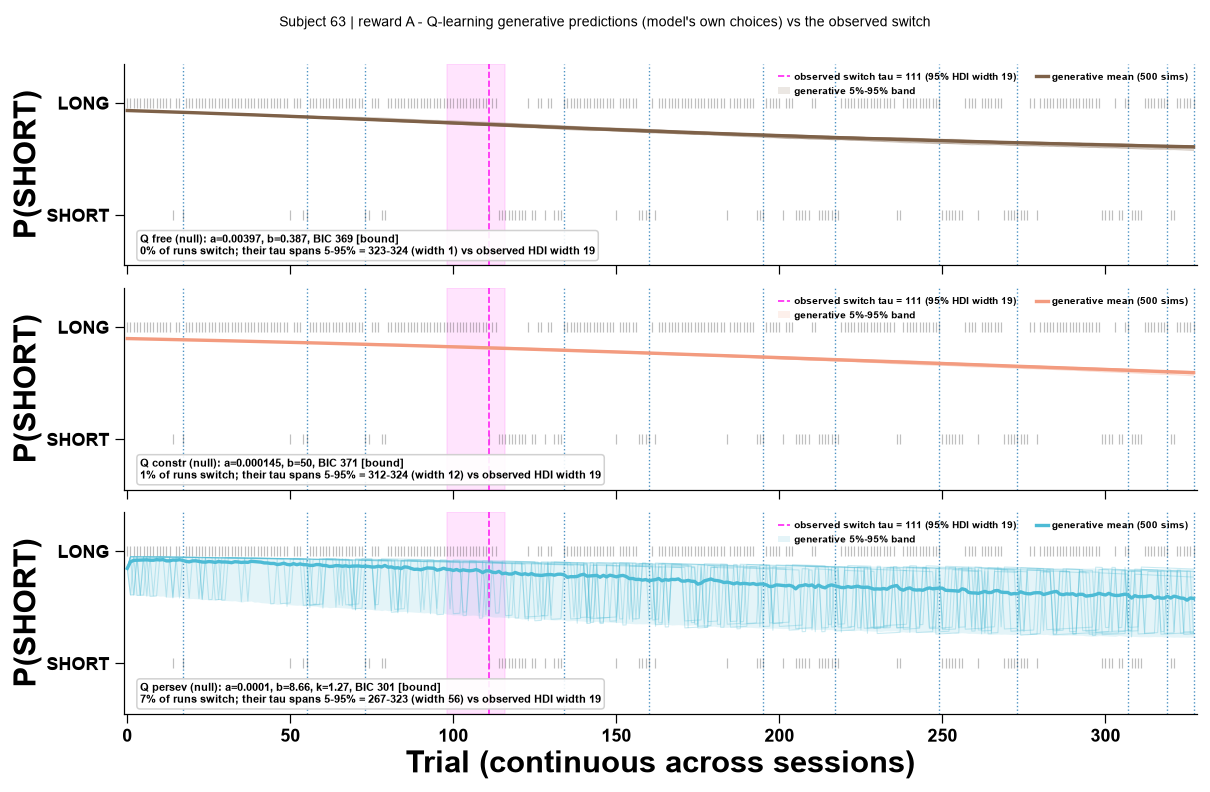

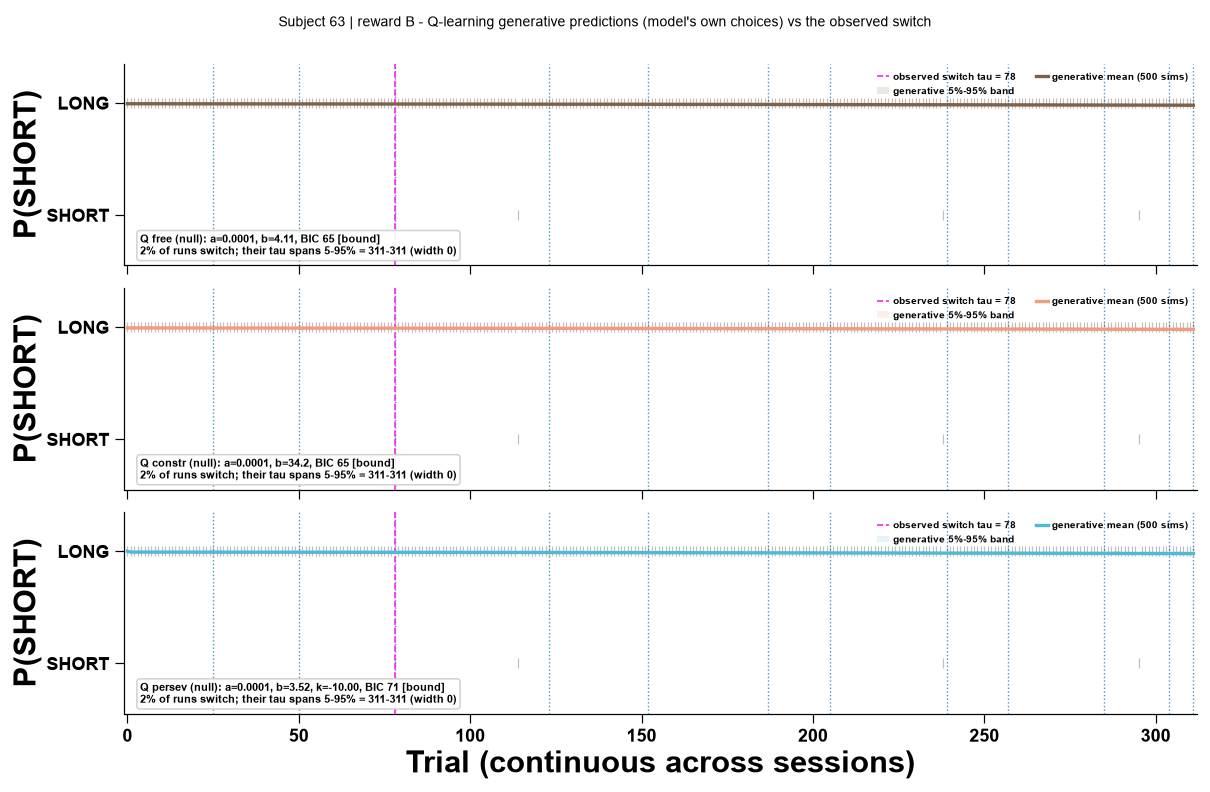

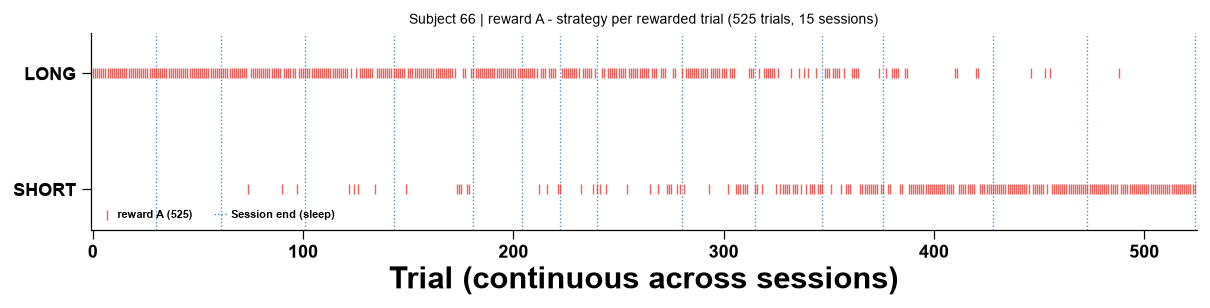

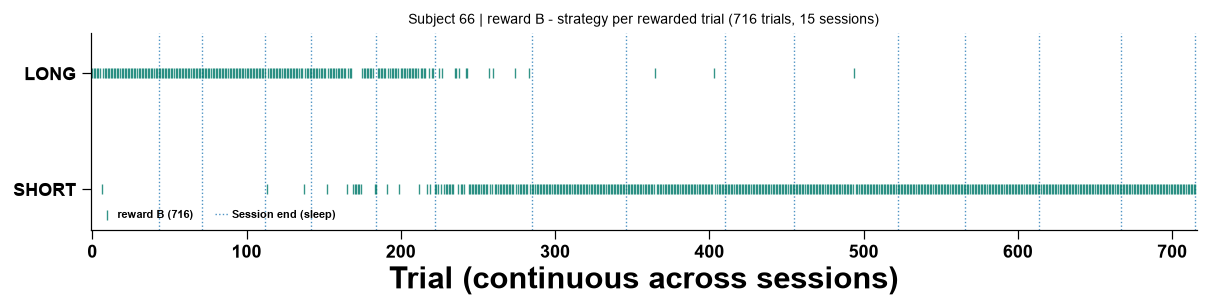

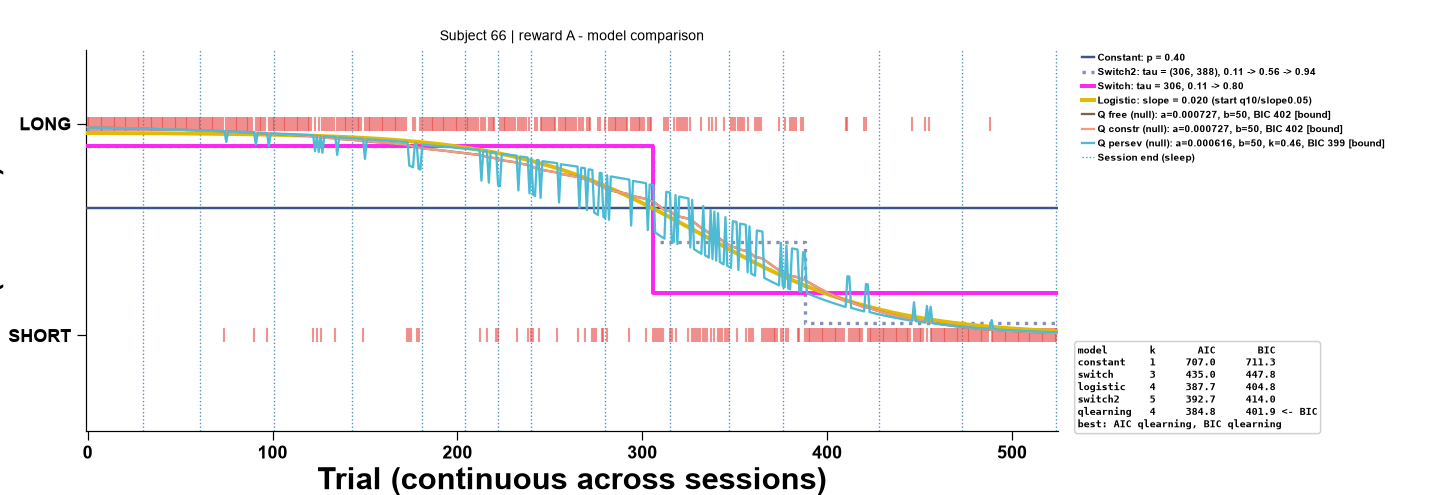

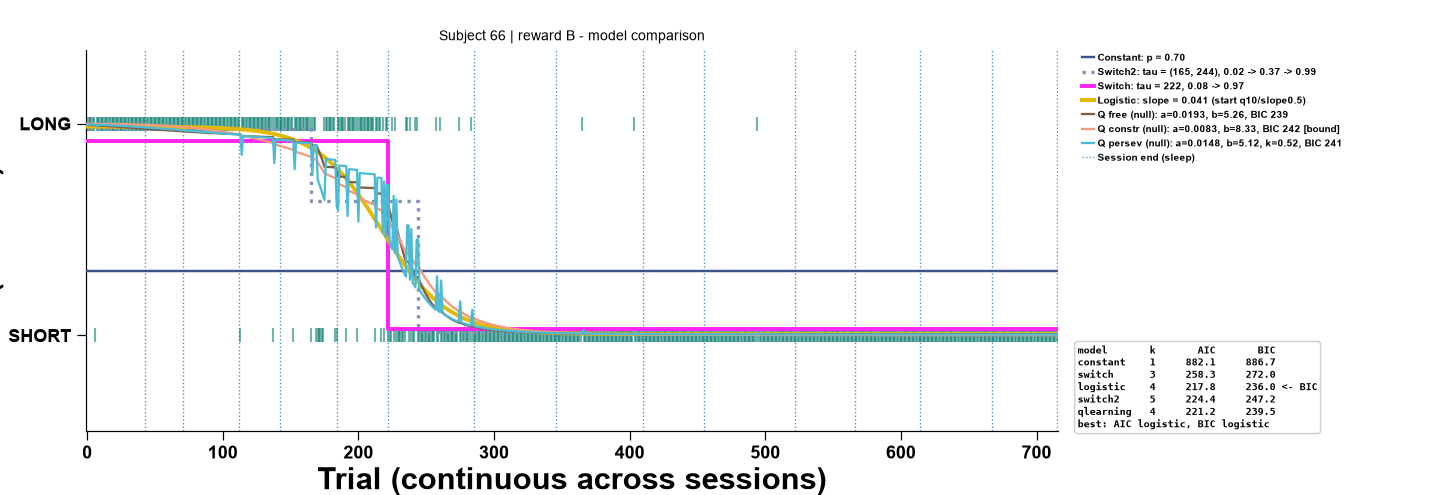

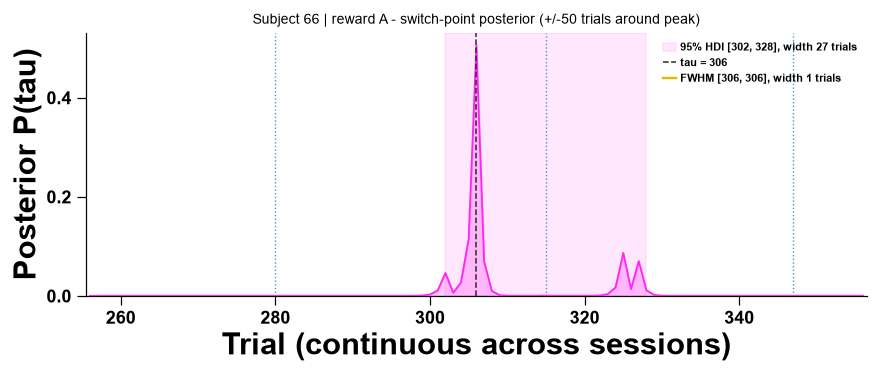

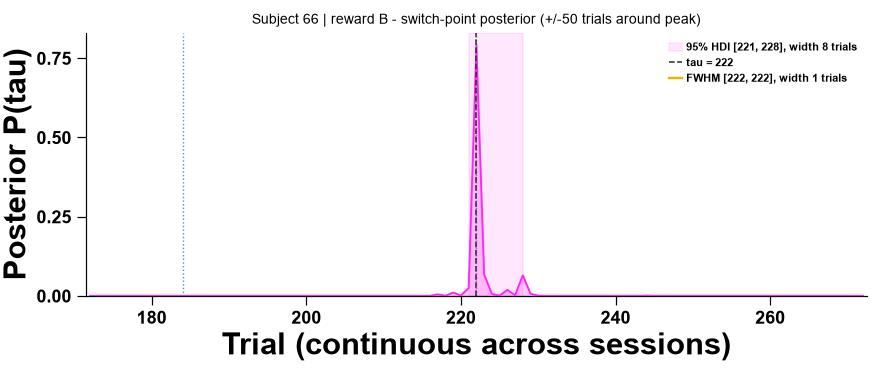

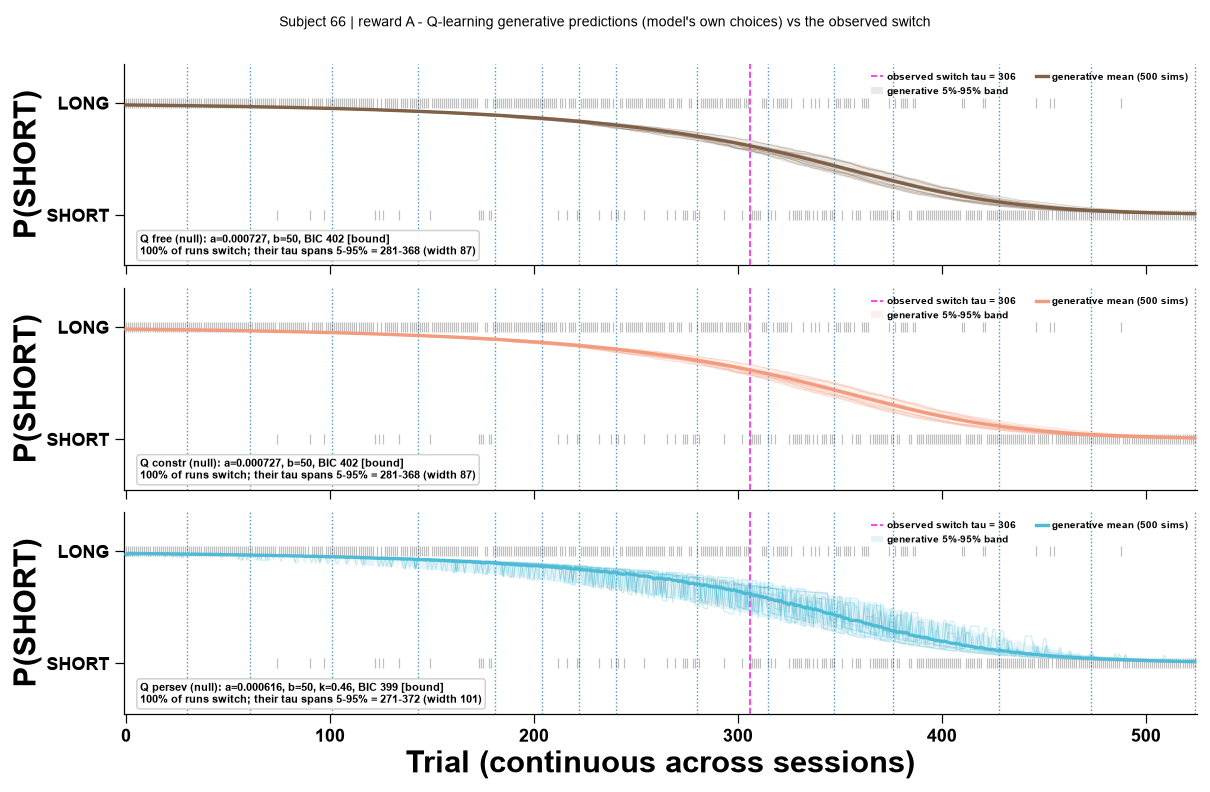

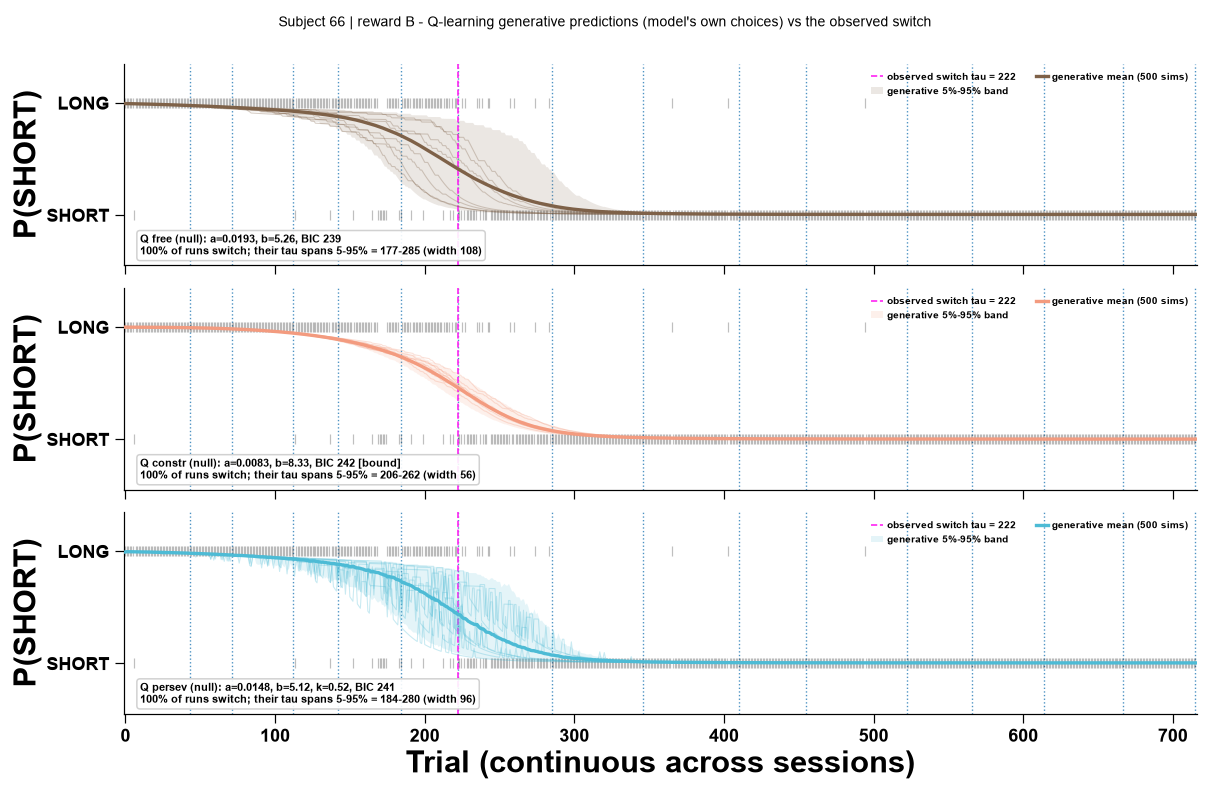

In [4]:
results = run_analysis(
    subjids=subjids_2,
    date_ranges=date_ranges_2,
    rewarded_only=True,
    likelihood_window=50,
    split_ab=True,
    show=True,
    around_switch=False, # Only plot X trials around switchpoint (set by plot_trials)
    plot_trials=200, 
    save=True
)

In [ ]:
q_sweep = run_qlearning_sweep(
    subjids=45,
    date_ranges=(20260213, 20260306),
    rewarded_only=True,
    split_ab=True,
    show=True,
)

In [ ]:
perm = run_permutation(
    subjids=subjids,
    date_ranges=date_ranges,
    rewarded_only=True,
    inclusion = "bic_switch_wins",
    n_permutations=1000,
    seed=0,
    show=True,
)

In [ ]:
run_logistic_diagnostic(
    subjids=subjids,
    date_ranges=date_ranges,
    rewarded_only=True,
    split_ab=True,
    show=True,
)

In [ ]:
run_residual_autocorrelation(
    subjids=subjids,
    date_ranges=date_ranges,
    rewarded_only=True,
    split_ab=True,
    show=True,
    max_lag=30
)